In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")

# Load Titanic dataset directly from URL
dataset_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(dataset_url)

# Display dataset dimensions and structure
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Data Types & Missing Values Info:")
df.info()

# Summary statistics for numerical features
display(df.describe())

# Inspect the first and last few rows
display(df.head())
display(df.tail())

Dataset Shape: 891 rows, 12 columns

Data Types & Missing Values Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [13]:
# Question 1: Survival rate by Passenger Class and Sex
survival_by_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
print("1. Survival Rate by Class and Sex:")
display(survival_by_class_sex)

# Question 2: Average Age and Fare for Survivors vs Non-Survivors
metrics_by_survival = df.groupby('Survived')[['Age', 'Fare']].mean()
print("\n2. Average Age and Fare by Survival Status:")
display(metrics_by_survival)

# Question 3: Survival rate based on Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
survival_by_family = df.groupby('FamilySize')['Survived'].agg(['count', 'mean']).rename(columns={'mean': 'SurvivalRate'})
print("\n3. Survival Rate by Family Size:")
display(survival_by_family)

1. Survival Rate by Class and Sex:


,Pclass,Sex,Survived
0,1,female,0.968085
1,1,male,0.368852
2,2,female,0.921053
3,2,male,0.157407
4,3,female,0.500000
5,3,male,0.135447



2. Average Age and Fare by Survival Status:


,Age,Fare
Survived,,
0,30.626179,22.117887
1,28.343690,48.395408



3. Survival Rate by Family Size:


,count,SurvivalRate
FamilySize,,
1,537,0.303538
2,161,0.552795
3,102,0.578431
4,29,0.724138
5,15,0.200000
6,22,0.136364
7,12,0.333333
8,6,0.000000
11,7,0.000000


In [14]:
# Comparing .groupby() and .pivot_table() for Question 1
groupby_summary = df.groupby(['Pclass', 'Sex'])['Survived'].mean()
pivot_summary = df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean')

print("--- Groupby Output ---")
print(groupby_summary)

print("\n--- Pivot Table Output ---")
print(pivot_summary)

--- Groupby Output ---
Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

--- Pivot Table Output ---
Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


> **Comparison Note:**  
> The `pivot_table` method feels more natural for analyzing two categorical dimensions (`Pclass` vs `Sex`) because it presents the result in a clear, 2D matrix layout. In contrast, `groupby` produces a multi-indexed Series which requires unstacking or additional formatting to achieve the same readability.

C:\Users\USER-PC\AppData\Local\Temp\ipykernel_17180\3273834165.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Fare', palette='Pastel1', ax=axes[2])


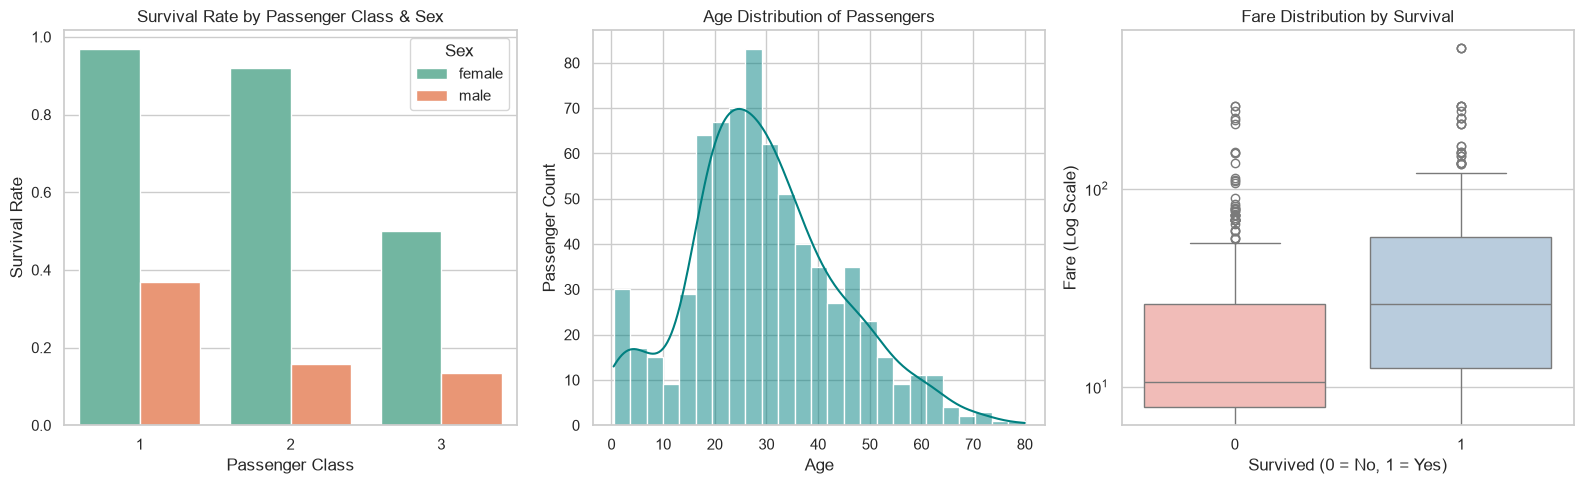

In [15]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Survival Rate by Passenger Class & Sex
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', errorbar=None, ax=axes[0], palette='Set2')
axes[0].set_title('Survival Rate by Passenger Class & Sex')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate')

# Plot 2: Age Distribution
sns.histplot(df['Age'].dropna(), kde=True, bins=25, color='teal', ax=axes[1])
axes[1].set_title('Age Distribution of Passengers')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Passenger Count')

# Plot 3: Fare Distribution by Survival Status
sns.boxplot(data=df, x='Survived', y='Fare', palette='Pastel1', ax=axes[2])
axes[2].set_yscale('log')  # Apply log scale for better visualization of fare spread
axes[2].set_title('Fare Distribution by Survival')
axes[2].set_xlabel('Survived (0 = No, 1 = Yes)')
axes[2].set_ylabel('Fare (Log Scale)')

plt.tight_layout()
plt.show()

### Summary
* Women and children had a much higher chance of survival than men.
* Passengers in 1st class survived more than those in 3rd class because they had better access to lifeboats.
* People who paid higher ticket fares had a better chance of surviving.
* Most passengers on the ship were young adults aged between 20 and 35.
* Small families had a better survival rate compared to people traveling alone or in very large families.

**Question for Next Time:**
I want to check if the cabin location on the ship affected who survived.